In [ ]:
%load_ext autoreload
%autoreload 2
from dataclasses import replace
from rankers.config import Config
from rankers.simulate import run, run_replicates, run_replicates_and_save_all_trajectories, run_matrix_sweep
import numpy as np
import matplotlib.pyplot as plt

base = Config(
    n=100,
    k=16,
    p_rewire=0.01,

    n_claims=200,
    claim_scheme="disinfo",
    llr_mag=1.0,

    repertoire_seed_size=5,
    belief_std=0.5,

    history_window=5,
    n_surfaced=1,
    ranker="baseline",
    receiver="neighbors",

    biases=("baseline",),
    emission_temp=1,
    n_steps=8000,
    record_every=20,
    n_tracked=50,
    seed=41,
)

In [2]:

# N biases x M rankers to sweep
# Each bias entry: (bias_name, extra config overrides to activate it)
bias_configs = [
    ("baseline",       dict()),
    ("confirmation",   dict(confirmation_strength=1.0)),
    ("negativity",     dict(negativity_multiplier=2.0)),
    ("illusory_truth", dict()),   # illusory_truth_factor=3.0 is already the default
    ("conservatism",   dict(conservatism_strength=1.0)),
]

ranker_names = ["baseline", "similarity", "engagement", "post_popularity", "user_popularity", "chronological"]

print(f"Matrix size: {len(bias_configs)} biases × {len(ranker_names)} rankers = {len(bias_configs)*len(ranker_names)} conditions")


Matrix size: 5 biases × 6 rankers = 30 conditions


In [4]:
matrix = run_matrix_sweep(base, bias_configs, ranker_names, n_reps=20, parallel=True)

[1/30]  bias=baseline         ranker=baseline ...
[2/30]  bias=baseline         ranker=similarity ...
[3/30]  bias=baseline         ranker=engagement ...
[4/30]  bias=baseline         ranker=post_popularity ...
[5/30]  bias=baseline         ranker=user_popularity ...
[6/30]  bias=baseline         ranker=chronological ...
[7/30]  bias=confirmation     ranker=baseline ...
[8/30]  bias=confirmation     ranker=similarity ...
[9/30]  bias=confirmation     ranker=engagement ...
[10/30]  bias=confirmation     ranker=post_popularity ...
[11/30]  bias=confirmation     ranker=user_popularity ...
[12/30]  bias=confirmation     ranker=chronological ...
[13/30]  bias=negativity       ranker=baseline ...
[14/30]  bias=negativity       ranker=similarity ...
[15/30]  bias=negativity       ranker=engagement ...
[16/30]  bias=negativity       ranker=post_popularity ...
[17/30]  bias=negativity       ranker=user_popularity ...
[18/30]  bias=negativity       ranker=chronological ...
[19/30]  bias=illusory

In [5]:

# save matrix to a file
import pickle

with open("results/Experiment_2/matrix.pkl", "wb") as f:
    pickle.dump(matrix, f)


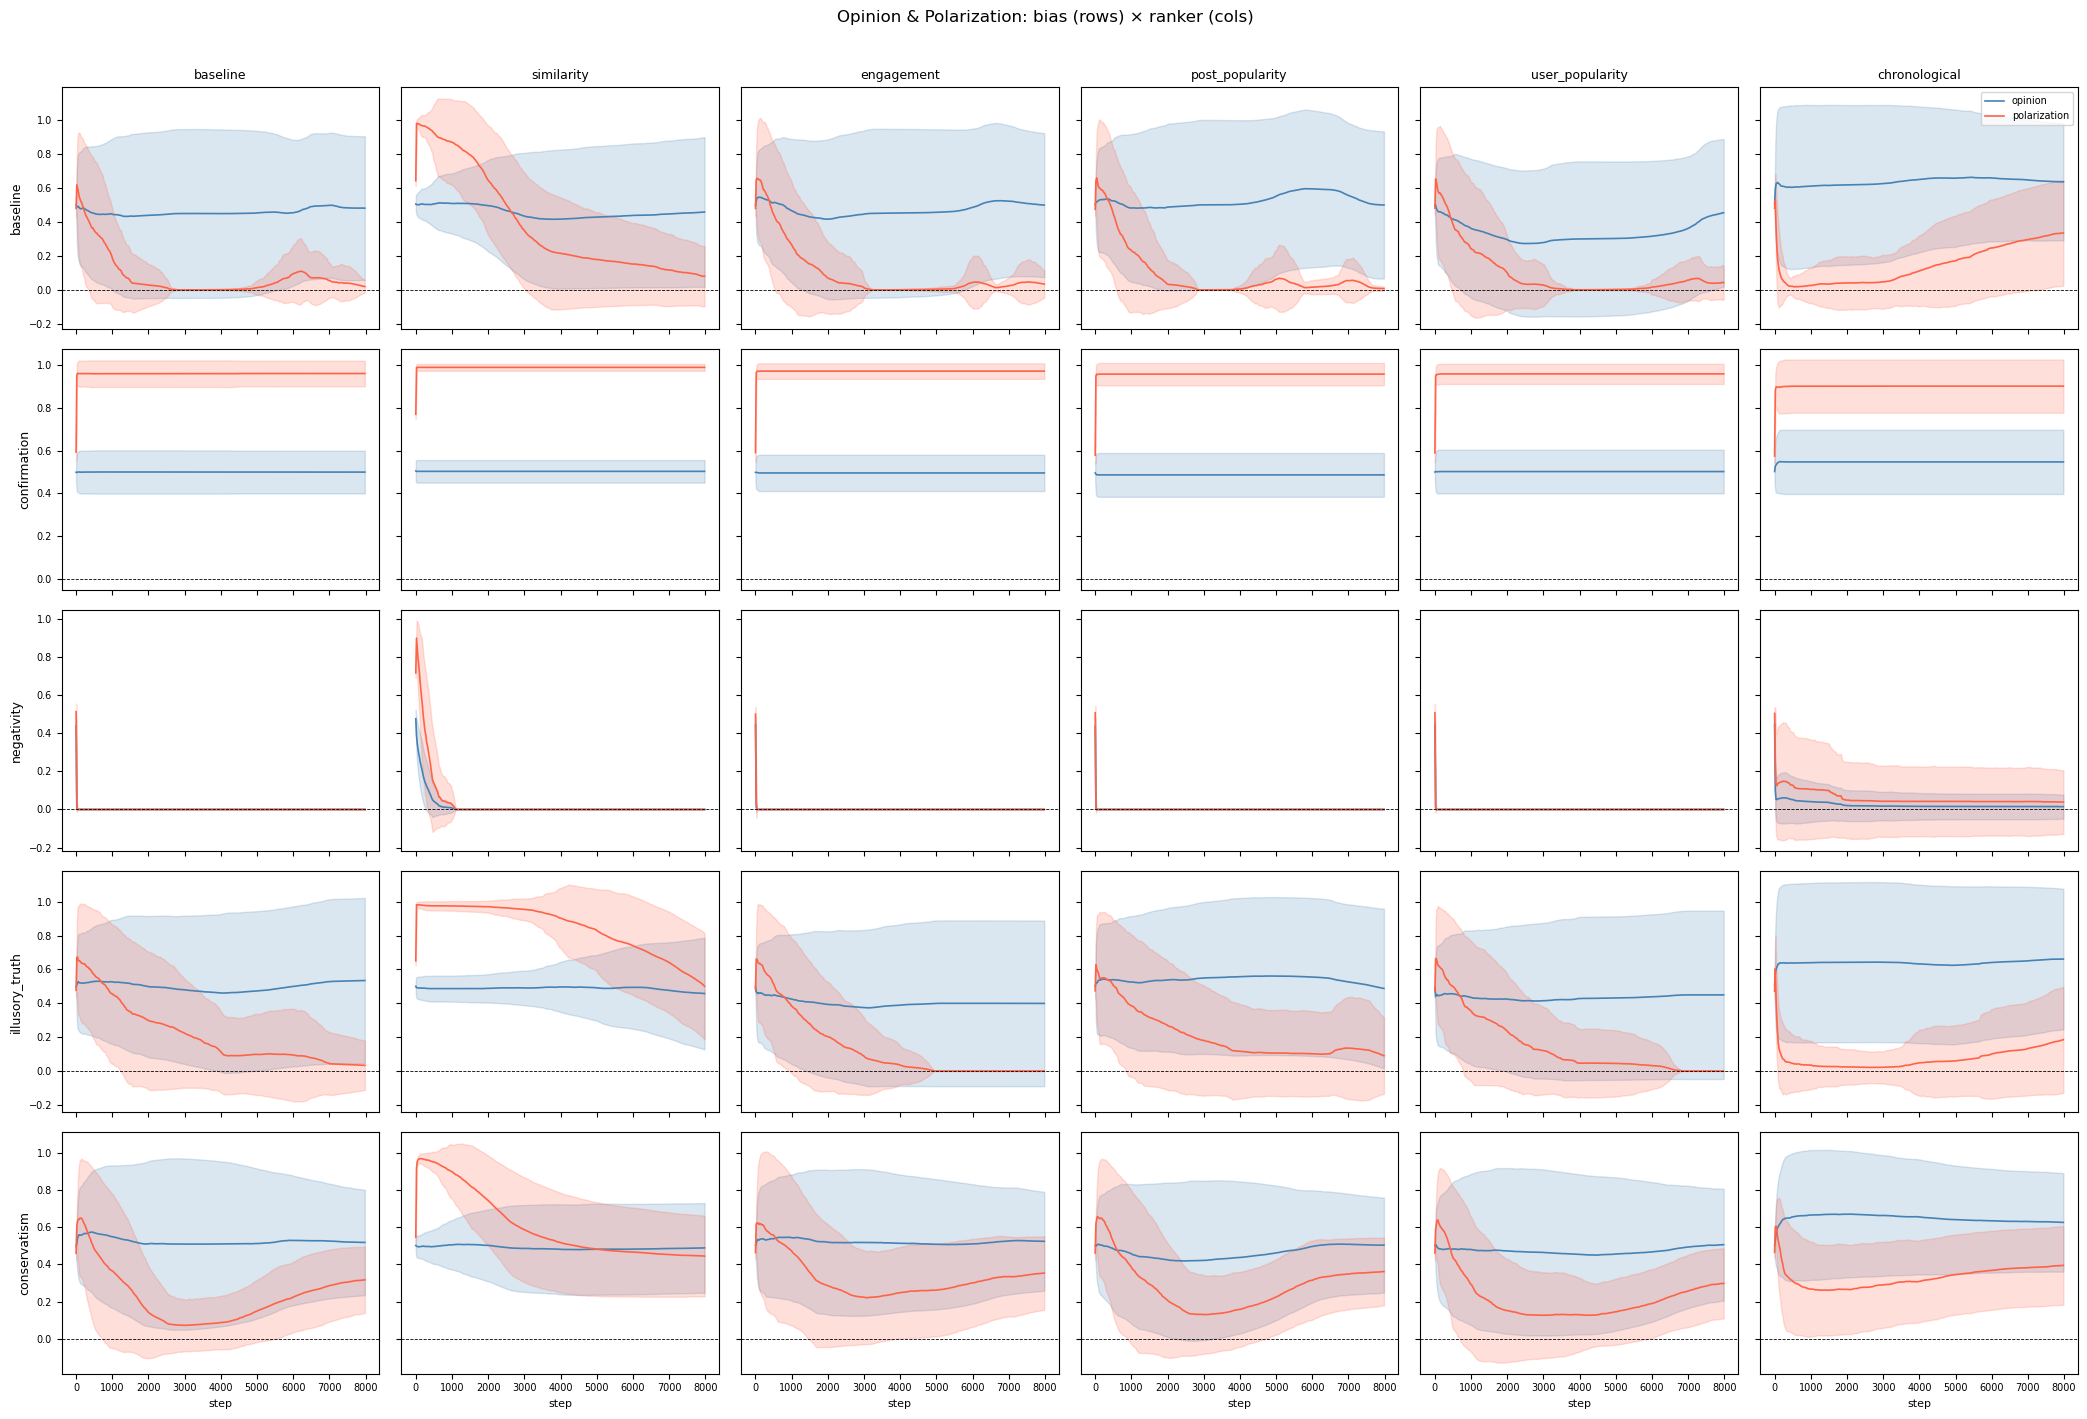

In [6]:

# Trajectory grid: N rows (biases) x M cols (rankers)
bias_names = [b for b, _ in bias_configs]
N, M = len(bias_names), len(ranker_names)

fig, axes = plt.subplots(N, M, figsize=(3.5 * M, 2.8 * N), sharex=True, sharey="row")

for i, bias_name in enumerate(bias_names):
    for j, ranker in enumerate(ranker_names):
        ax = axes[i, j]
        agg = matrix[bias_name][ranker]

        for metric, color in [("opinion", "steelblue"), ("polarization", "tomato")]:
            m = agg["mean"][metric]
            s = agg["std"][metric]
            t = np.arange(len(m)) * base.record_every
            ax.plot(t, m, color=color, lw=1.2, label=metric)
            ax.fill_between(t, m - s, m + s, color=color, alpha=0.2)

        ax.axhline(0, color="black", lw=0.6, ls="--")
        ax.tick_params(labelsize=7)
        if i == 0:
            ax.set_title(ranker, fontsize=9)
        if j == 0:
            ax.set_ylabel(bias_name, fontsize=9)
        if i == N - 1:
            ax.set_xlabel("step", fontsize=8)

axes[0, -1].legend(fontsize=7, loc="upper right")
fig.suptitle("Opinion & Polarization: bias (rows) × ranker (cols)", fontsize=12, y=1.01)
plt.tight_layout()
plt.show()


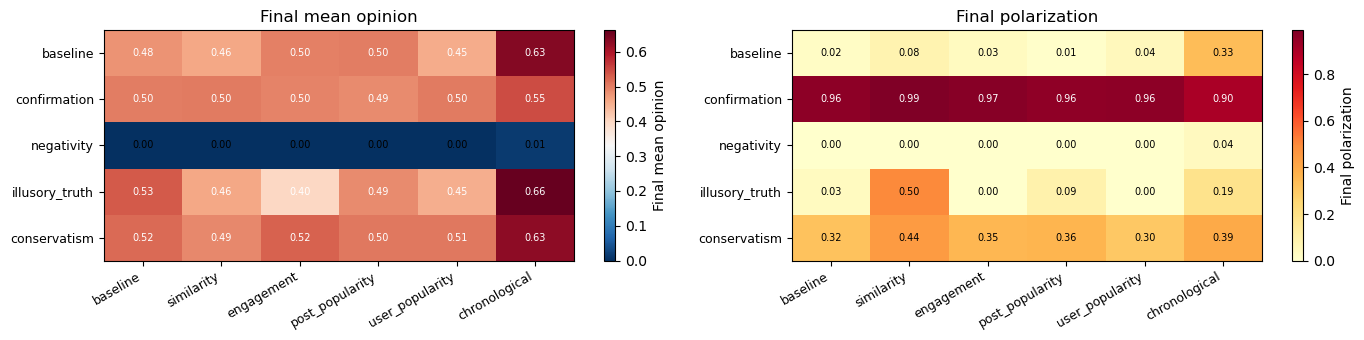

In [7]:

# Heatmaps: final opinion and final polarization for each (bias, ranker) pair
bias_names = [b for b, _ in bias_configs]

final_opinion = np.array([
    [matrix[b][r]["mean"]["opinion"][-1] for r in ranker_names]
    for b in bias_names
])
final_polarization = np.array([
    [matrix[b][r]["mean"]["polarization"][-1] for r in ranker_names]
    for b in bias_names
])

fig, axes = plt.subplots(1, 2, figsize=(14, 3.5))

for ax, data, title, cmap in [
    (axes[0], final_opinion,      "Final mean opinion",    "RdBu_r"),
    (axes[1], final_polarization, "Final polarization",    "YlOrRd"),
]:
    im = ax.imshow(data, aspect="auto", cmap=cmap)
    ax.set_xticks(range(len(ranker_names)))
    ax.set_xticklabels(ranker_names, rotation=30, ha="right", fontsize=9)
    ax.set_yticks(range(len(bias_names)))
    ax.set_yticklabels(bias_names, fontsize=9)
    for i in range(len(bias_names)):
        for j in range(len(ranker_names)):
            ax.text(j, i, f"{data[i, j]:.2f}", ha="center", va="center", fontsize=7,
                    color="white" if abs(data[i, j]) > 0.6 * data.max() else "black")
    plt.colorbar(im, ax=ax, label=title)
    ax.set_title(title)

plt.tight_layout()
plt.show()
